In [4]:
from pathlib import Path
import cv2

# Get target / ref image pair
target_path = Path('/home/khw/Documents/6dpose/LightGlue/myassets/frame_000050_crop.png')
ref_path = Path('/home/khw/Documents/6dpose/LightGlue/myassets/frame_000061_crop.png')


In [2]:
# TEST: Read aruco marker image
aruco_path = '/home/khw/Documents/6dpose/Image-Based-Visual-Servoing/src/static/aruco_marker.png'
aruco_img = cv2.imread(aruco_path)

Run SuperPoint feature detector on its own (without feature matching)

In [30]:
from servo import *   # methods from original script
from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd, resize_image
from lightglue import viz2d

import torch
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'
extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor

In [31]:
image0 = load_image("/home/khw/Documents/6dpose/Image-Based-Visual-Servoing/src/dist_img/distance_image_0.png")
feats0 = extractor.extract(image0.to(device))

In [32]:
image0.shape

torch.Size([3, 500, 800])

In [33]:
feats0['keypoints'].shape  # number of keypoints detected

torch.Size([1, 577, 2])

If using load_im

In [ ]:
def load_image(path: Path, resize: int = None, **kwargs) -> torch.Tensor:
    image = read_image(path)
    if resize is not None:
        image, _ = resize_image(image, resize, **kwargs)
    return numpy_image_to_torch(image)

In [ ]:
def read_image(path: Path, grayscale: bool = False) -> np.ndarray:
    """Read an image from path as RGB or grayscale"""
    if not Path(path).exists():
        raise FileNotFoundError(f"No image at path {path}.")
    mode = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    image = cv2.imread(str(path), mode)
    if image is None:
        raise IOError(f"Could not read image at {path}.")
    if not grayscale:
        image = image[..., ::-1]
    return image

In [39]:
from lightglue.utils import numpy_image_to_torch, read_image

In [ ]:
def read_image(path: Path, grayscale: bool = False) -> np.ndarray:
    """Read an image from path as RGB or grayscale"""
    if not Path(path).exists():
        raise FileNotFoundError(f"No image at path {path}.")
    mode = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    image = cv2.imread(str(path), mode)
    if image is None:
        raise IOError(f"Could not read image at {path}.")
    if not grayscale:
        image = image[..., ::-1]
    return image

In [46]:
# valid cell
impath = "/home/khw/Documents/6dpose/Image-Based-Visual-Servoing/src/dist_img/distance_image_0.png"
testim = read_image(impath)
testim = numpy_image_to_torch(testim)

print(f"testim shape: {testim.shape}")
print(f"testim dtype: {testim.dtype}")
print(f"testim device: {testim.device}")

newfeats = extractor.extract(testim.to(device))
newfeats['keypoints'].shape

torch.Size([1, 577, 2])

Read image from PyBullet

Getting getting matched SuperPoints between images

In [3]:
from servo_new import match_superpoints

# get superpoints from both images
m_kpts0, m_kpts1 = match_superpoints(target_path, ref_path)

1. naive translational displacement

In [4]:
m_kpts0

tensor([[ 84.8125,   7.3125],
        [ 99.1875,   7.3125],
        [ 95.4375,   7.9375],
        [114.1875,   7.9375],
        [ 95.4375,  14.8125],
        [ 77.9375,  15.4375],
        [ 87.3125,  15.4375],
        [126.6875,  17.3125],
        [199.1875,  19.8125],
        [204.8125,  24.1875],
        [136.0625,  25.4375],
        [ 95.4375,  27.9375],
        [124.1875,  31.0625],
        [ 95.4375,  31.6875],
        [127.3125,  31.6875],
        [ 78.5625,  34.8125],
        [ 80.4375,  38.5625],
        [103.5625,  39.1875],
        [176.6875,  42.9375],
        [227.3125,  44.8125],
        [230.4375,  48.5625],
        [113.5625,  49.8125],
        [113.5625,  52.9375],
        [199.8125,  52.9375],
        [237.3125,  55.4375],
        [222.9375,  63.5625],
        [244.1875,  65.4375],
        [246.6875,  68.5625],
        [111.0625,  70.4375],
        [251.0625,  74.8125],
        [ 76.6875,  77.9375],
        [254.1875,  81.6875],
        [222.9375,  82.3125],
        [ 

In [5]:
from servo_new import compute_motion_vector

# 1. naive translational displacement
motion_vec = compute_motion_vector(m_kpts0, m_kpts1)

motion_vec # check if it roughly matches the plotted images

(np.float32(0.2990903), np.float32(0.9542248))

2. Homography matrix for pose discrepancies estimation between video 

In [6]:
import cv2

assets_path = Path('/home/khw/Documents/6dpose/LightGlue/myassets/')
source_im = cv2.imread(assets_path / 'frame_000050_crop.png')
target_im = cv2.imread(assets_path / 'frame_000061_crop.png')

In [7]:
# points to homography
m_kpts0 = m_kpts0.reshape(-1, 1, 2)
m_kpts1 = m_kpts1.reshape(-1, 1, 2)

import numpy as np
m_kpts0 = np.array(m_kpts0.cpu())
m_kpts1 = np.array(m_kpts1.cpu())

/tmp/ipykernel_106486/2302370129.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  m_kpts0 = np.array(m_kpts0.cpu())
/tmp/ipykernel_106486/2302370129.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  m_kpts1 = np.array(m_kpts1.cpu())


In [8]:
m_kpts0.shape

(206, 1, 2)

In [9]:
import cv2
H, _ = cv2.findHomography(m_kpts0, m_kpts1)

In [10]:
H

array([[ 1.05920427e+00,  1.10163425e-01, -2.87982429e+01],
       [-2.15721888e-02,  9.51724768e-01,  6.58794055e+01],
       [-1.49909261e-04,  6.51560458e-06,  1.00000000e+00]])

In [11]:
img1_warp = cv2.warpPerspective(source_im, H, (source_im.shape[1], source_im.shape[0]))

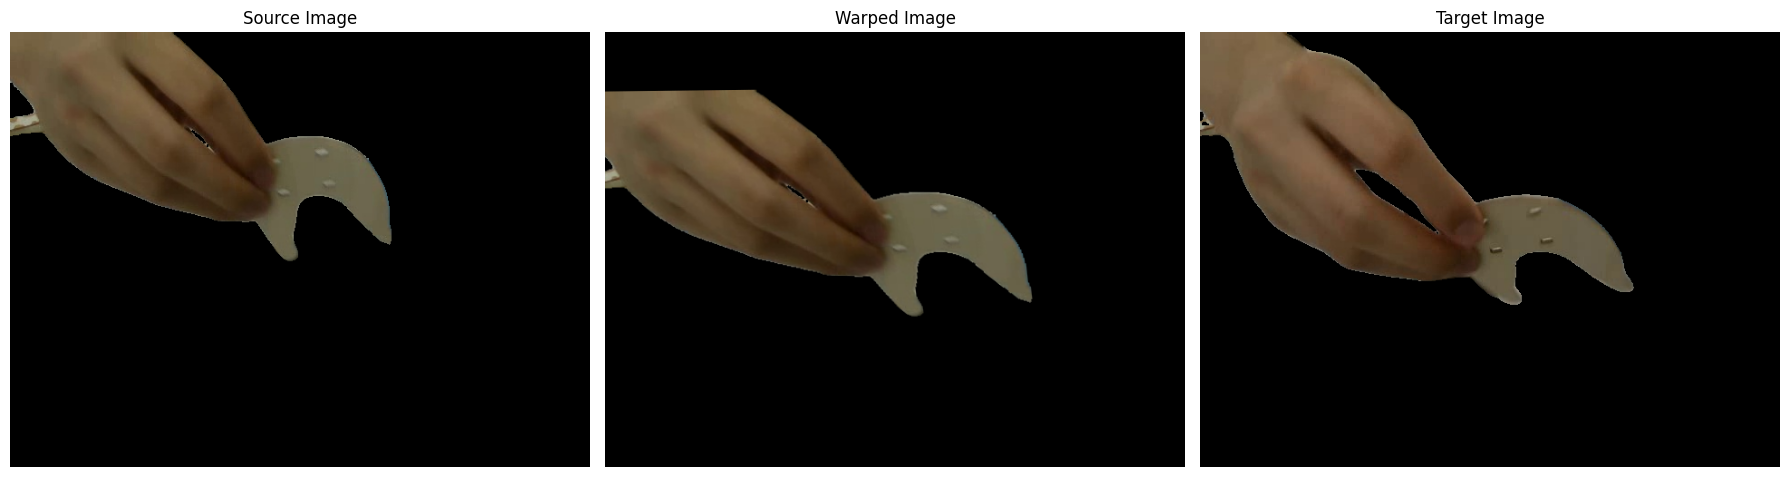

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

ax1.imshow(cv2.cvtColor(source_im, cv2.COLOR_BGR2RGB))
ax1.set_title('Source Image')
ax1.axis('off')

ax2.imshow(cv2.cvtColor(img1_warp, cv2.COLOR_BGR2RGB))
ax2.set_title('Warped Image')
ax2.axis('off')

ax3.imshow(cv2.cvtColor(target_im, cv2.COLOR_BGR2RGB))
ax3.set_title('Target Image')
ax3.axis('off')

plt.tight_layout()
plt.show()

**Problem :** The hand is flexible. **We must segment out the hand.**

## Test Jacobian

**Before we begin, how are points indexed in m_kpts0/1 ?**

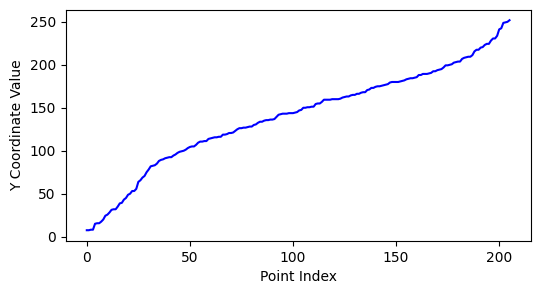

In [13]:
# Q: how are points indexed in m_kpts0/1 ?
import matplotlib.pyplot as plt

m_kpts0 = m_kpts0.reshape(-1, 2)  # reshape to [n x 2] matrix

coords = m_kpts0[:,1]

# Create indices
indices = range(len(coords))

plt.figure(figsize=(6,3))
plt.plot(indices, coords, 'b-')
plt.xlabel('Point Index')
plt.ylabel('Y Coordinate Value')
plt.show()


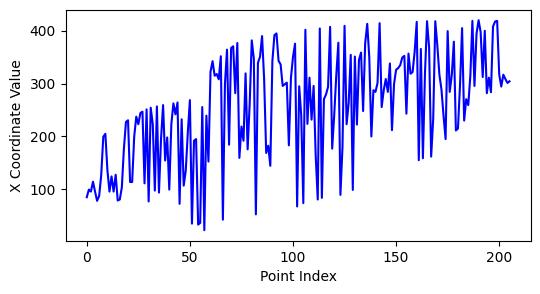

In [14]:
# Q: how are points indexed in m_kpts0/1 ?
import matplotlib.pyplot as plt

m_kpts0 = m_kpts0.reshape(-1, 2)  # reshape to [n x 2] matrix

x_coords = m_kpts0[:,0]

# Create indices for x-axis
indices = range(len(x_coords))

plt.figure(figsize=(6,3))
plt.plot(indices, x_coords, 'b-')
plt.xlabel('Point Index')
plt.ylabel('X Coordinate Value')
plt.show()


The answer is the points are sorted by **height**.

---

Next, test compute time with N = 8, ... points for Jacobian.

In [15]:
from motion_new import get_velocity_K_points

m_kpts0 = m_kpts0.reshape(-1, 2)
m_kpts1 = m_kpts1.reshape(-1, 2)

depth_buff = np.ones((480, 640), dtype=np.float32)
K = 3

assert m_kpts0.shape == m_kpts1.shape
m_kpts1.shape

control_vec = get_velocity_K_points(m_kpts0, m_kpts1, depth_buff, K)  # (6,)

Finall, integrate into PyBullet simulator.


# DO NOT USE:
All other experiments I've done

###
Task : Compute transformation that moves the target's pose to ref pose

Method : Copmute mapping homography matrix



In [16]:
import cv2 as cv
import cv2 

assets_path = Path('/home/khw/Documents/6dpose/Image-Based-Visual-Servoing/src/assets')
from lightglue.utils import load_image, rbd
source_im = cv2.imread(assets_path / 'chess_source.png')
target_im = cv2.imread(assets_path / 'chess_target.png')

patternSize = (9, 6)
ret1, corners1= cv2.findChessboardCorners(source_im, patternSize)
ret2, corners2  = cv2.findChessboardCorners(target_im, patternSize)


H, _ = cv.findHomography(corners1, corners2)

In [17]:
H

array([[ 3.26604661e-01, -1.24084637e+00,  5.85293255e+02],
       [ 6.95450495e-01, -8.32769793e-02, -9.36102298e+01],
       [ 3.68307932e-04, -9.79295070e-04,  1.00000000e+00]])

In [18]:
img1_warp = cv.warpPerspective(source_im, H, (source_im.shape[1], source_im.shape[0]))

In [19]:
cv.imshow('', img1_warp)
cv.waitKey() & 0xFF
cv.destroyAllWindows()